Epoch 1/10, Loss: 0.1098
Epoch 2/10, Loss: 0.0427
Epoch 3/10, Loss: 0.0288
Epoch 4/10, Loss: 0.0199
Epoch 5/10, Loss: 0.0137
Epoch 6/10, Loss: 0.0095
Epoch 7/10, Loss: 0.0068
Epoch 8/10, Loss: 0.0049
Epoch 9/10, Loss: 0.0036
Epoch 10/10, Loss: 0.0028


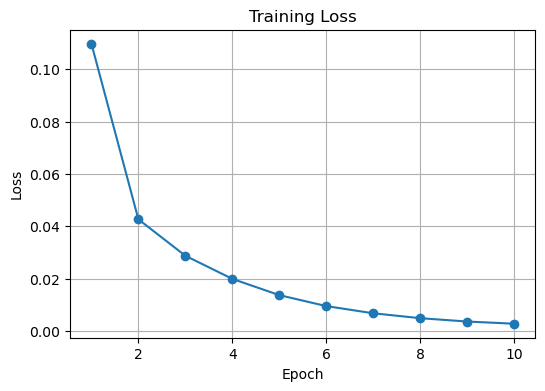

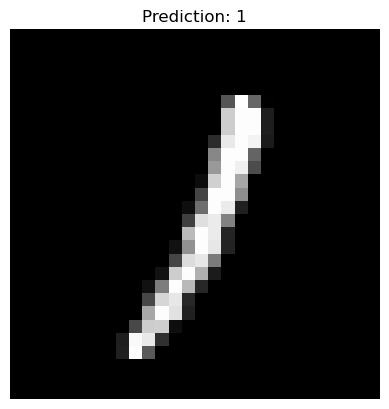

Actual Label     : 1
Predicted Label  : 1


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder
# Step 2: Load and Preprocess the Dataset
(X_train, y_train), (_, _) = mnist.load_data()

# Use only the first 5000 samples for faster training
X_train = X_train[:2000]
y_train = y_train[:2000]

# Flatten and normalize
X_train = X_train.reshape(-1, 784) / 255.0

# One-Hot Encode Labels
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))


input_size = 784
hidden_size = 64
output_size = 10
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

def loss_fn(y, y_hat):
    return -np.mean(y * np.log(y_hat + 1e-8))


epochs = 10
lr = 0.1
losses = []

for epoch in range(epochs):
    total_loss = 0

    for i in range(X_train.shape[0]):

        x = X_train[i:i+1]
        y = y_train[i:i+1]

        z1 = x @ W1 + b1
        a1 = sigmoid(z1)

        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        loss = loss_fn(y, a2)
        total_loss += loss
        
        dz2 = a2 - y
        dW2 = a1.T @ dz2
        db2 = dz2

        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)
        dW1 = x.T @ dz1
        db1 = dz1

        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1

    avg_loss = total_loss / X_train.shape[0]
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

def predict(img):
    img = img.reshape(1, 784) / 255.0

    a1 = sigmoid(img @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)

    return np.argmax(a2)

idx = 100

plt.imshow(X_train[idx-1].reshape(28, 28), cmap='gray')
plt.title(f"Prediction: {predict(X_train[idx-1])}")
plt.axis('off')
plt.show()

print("Actual Label     :", np.argmax(y_train[idx-1]))
print("Predicted Label  :", predict(X_train[idx-1]))